# Temp-Controlled RAPL Analysis

This notebook explores the run-level summary in `temp_controlled_runs.csv` and one or more per-ms traces from `temp_controlled_samples/`.

The sample files contain repeated rows for each metric, so the notebook reshapes them into a simple time series before plotting.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

base_dir = Path("logs/temp_controlled_logs")
runs_path = base_dir / "temp_controlled_runs.csv"
sample_dir = base_dir / "temp_controlled_samples"

runs = pd.read_csv(runs_path)
runs["timestamp_utc"] = pd.to_datetime(runs["timestamp_utc"], utc=True, errors="coerce")
runs = runs.sort_values(["query_filter", "loop_index", "timestamp_utc"])

print(f"Runs: {runs.shape[0]} rows, {runs.shape[1]} columns")
display(runs.head())
display(runs.dtypes.to_frame("dtype"))

Runs: 242 rows, 22 columns


,timestamp_utc,run_id,test_name,loop_index,loops,runs_per_loop,total_runs,total_elapsed_sec,failures,rapl_package_j,...,rapl_dram_j,start_pkg_tmp_c,end_pkg_tmp_c,cooldown_wait_sec,cooldown_threshold_c,rapl_1ms_file,query_dir,query_filter,sigless_addr,run_started_utc
0,2026-04-20 11:33:36+00:00,2FFFF73F79C292CE,APX1145-queryA.sql,1,1,1,1,1.583717,0,35.887817,...,NaN,32.0,35.0,16.053275,40.0,logs/temp_controlled_samples/2FFFF73F79C292CE_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:33:15Z
1,2026-04-20 11:33:39+00:00,2FFFF73F79C292CE,APX1145-queryB.sql,1,1,1,1,0.492680,0,11.303772,...,NaN,33.0,34.0,0.000000,40.0,logs/temp_controlled_samples/2FFFF73F79C292CE_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:33:15Z
2,2026-04-20 11:34:38+00:00,1C899B7B2AD1B571,APX1145-queryA.sql,1,10,1,10,0.604760,0,28.885681,...,NaN,34.0,34.0,16.050295,40.0,logs/temp_controlled_samples/1C899B7B2AD1B571_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:34:18Z
12,2026-04-20 11:37:45+00:00,1C899B7B2AD1B571,APX1145-queryB.sql,1,10,1,10,0.444834,0,25.473145,...,NaN,35.0,36.0,16.049907,40.0,logs/temp_controlled_samples/1C899B7B2AD1B571_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:34:18Z
3,2026-04-20 11:34:57+00:00,1C899B7B2AD1B571,APX1145-queryA.sql,2,10,1,10,0.599023,0,29.008240,...,NaN,34.0,35.0,16.043072,40.0,logs/temp_controlled_samples/1C899B7B2AD1B571_...,queries,APX1145,127.0.0.1:8000,2026-04-20T11:34:18Z


,dtype
timestamp_utc,"datetime64[ns, UTC]"
run_id,object
test_name,object
loop_index,int64
loops,int64
runs_per_loop,int64
total_runs,int64
total_elapsed_sec,float64
failures,int64
rapl_package_j,float64


## Load and Inspect temp_controlled_samples

In [2]:
sample_files = sorted(sample_dir.glob("*.csv"))
print(f"Sample files: {len(sample_files)}")
display([path.name for path in sample_files[:5]])

sample_columns = [
    "timestamp_sec",
    "joules",
    "unit",
    "metric_path",
    "raw_counter",
    "percent",
    "extra_1",
    "extra_2",
]

def load_sample(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(
        path,
        header=None,
        comment="#",
        names=sample_columns,
        usecols=[0, 1, 2, 3, 4, 5],
    )
    raw["metric"] = raw["metric_path"].str.replace("power/energy-", "", regex=False).str.replace("/", "", regex=False)
    wide = (
        raw.pivot_table(index="timestamp_sec", columns="metric", values="joules", aggfunc="last")
        .reset_index()
        .sort_values("timestamp_sec")
    )
    return wide

first_sample = load_sample(sample_files[0]) if sample_files else pd.DataFrame()
print("First sample file:", sample_files[0].name if sample_files else "none")
display(first_sample.head())
display(pd.DataFrame({"column": first_sample.columns}) if not first_sample.empty else pd.DataFrame())

Sample files: 242


['1C899B7B2AD1B571__APX1145-queryA.sql__loop10_run1.rapl.csv',
 '1C899B7B2AD1B571__APX1145-queryA.sql__loop1_run1.rapl.csv',
 '1C899B7B2AD1B571__APX1145-queryA.sql__loop2_run1.rapl.csv',
 '1C899B7B2AD1B571__APX1145-queryA.sql__loop3_run1.rapl.csv',
 '1C899B7B2AD1B571__APX1145-queryA.sql__loop4_run1.rapl.csv']

First sample file: 1C899B7B2AD1B571__APX1145-queryA.sql__loop10_run1.rapl.csv


metric,timestamp_sec,cores,gpu,pkg,ram
0,0.001103,0.01,0.0,0.01,0.0
1,0.002453,0.01,0.0,0.02,0.0
2,0.003580,0.01,0.0,0.01,0.0
3,0.004705,0.01,0.0,0.01,0.0
4,0.005800,0.01,0.0,0.01,0.0


,column
0,timestamp_sec
1,cores
2,gpu
3,pkg
4,ram


## Compare QueryA vs QueryB at Run Level by Test Name

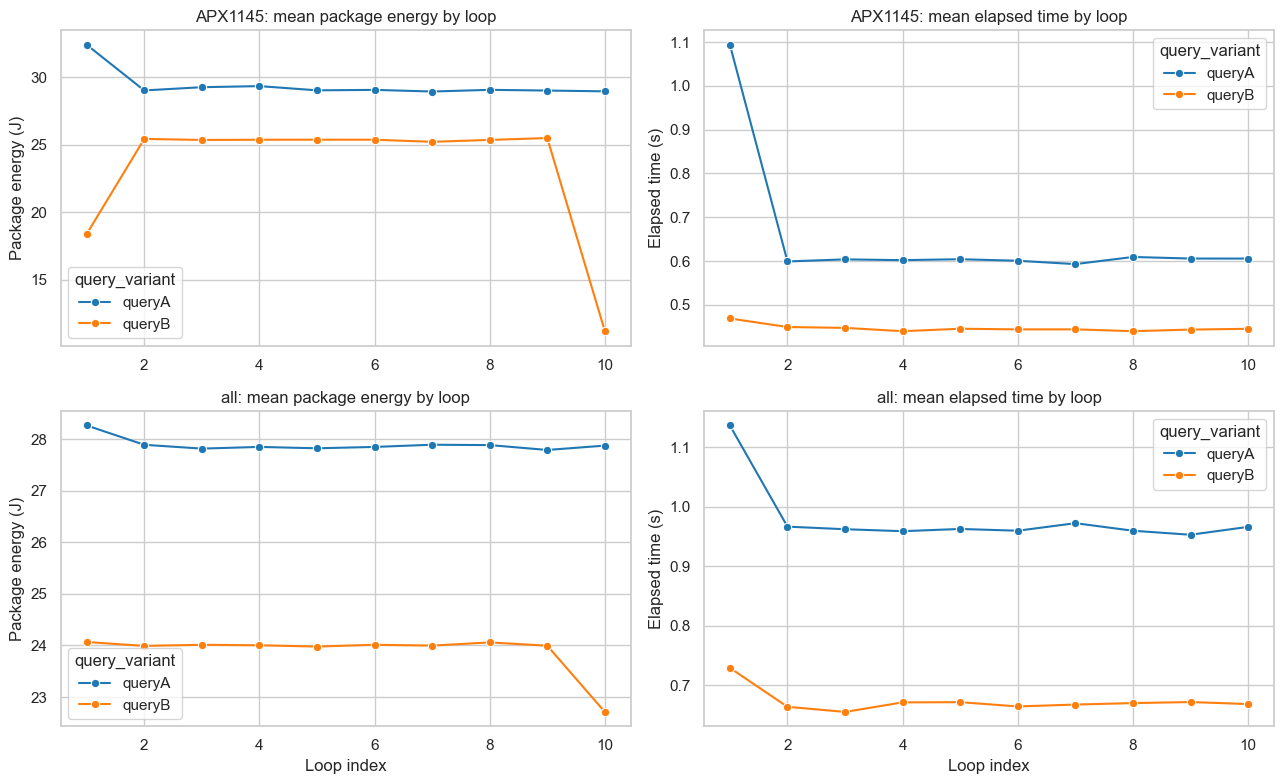

In [10]:
runs_cmp = runs.copy()
runs_cmp["query_variant"] = runs_cmp["test_name"].str.extract(r"(queryA|queryB)", expand=False)
runs_cmp["test_group"] = runs_cmp["query_filter"].fillna(
    runs_cmp["test_name"].str.extract(r"^(.*?)-query[AB]", expand=False)
)
runs_cmp = runs_cmp[runs_cmp["query_variant"].isin(["queryA", "queryB"])].copy()

groups = [group for group in runs_cmp["test_group"].dropna().drop_duplicates().sort_values()]

if not groups:
    print("No queryA/queryB runs found.")
else:
    fig, axes = plt.subplots(len(groups), 2, figsize=(13, 4 * len(groups)), squeeze=False)
    colors = {"queryA": "tab:blue", "queryB": "tab:orange"}

    for row_index, group in enumerate(groups):
        group_runs = runs_cmp[runs_cmp["test_group"] == group].copy()
        by_loop = (
            group_runs.groupby(["loop_index", "query_variant"], as_index=False)
            .agg(
                total_elapsed_sec=("total_elapsed_sec", "mean"),
                rapl_package_j=("rapl_package_j", "mean"),
                start_pkg_tmp_c=("start_pkg_tmp_c", "mean"),
                end_pkg_tmp_c=("end_pkg_tmp_c", "mean"),
            )
            .sort_values(["loop_index", "query_variant"])
        )

        package_ax = axes[row_index, 0]
        elapsed_ax = axes[row_index, 1]

        sns.lineplot(
            data=by_loop,
            x="loop_index",
            y="rapl_package_j",
            hue="query_variant",
            marker="o",
            palette=colors,
            ax=package_ax,
        )
        package_ax.set_title(f"{group}: mean package energy by loop")
        package_ax.set_xlabel("Loop index")
        package_ax.set_ylabel("Package energy (J)")
        if row_index < len(groups) - 1:
            package_ax.set_xlabel("")

        sns.lineplot(
            data=by_loop,
            x="loop_index",
            y="total_elapsed_sec",
            hue="query_variant",
            marker="o",
            palette=colors,
            ax=elapsed_ax,
        )
        elapsed_ax.set_title(f"{group}: mean elapsed time by loop")
        elapsed_ax.set_xlabel("Loop index")
        elapsed_ax.set_ylabel("Elapsed time (s)")
        if row_index < len(groups) - 1:
            elapsed_ax.set_xlabel("")

        for plot_ax in (package_ax, elapsed_ax):
            plot_ax.legend(title="query_variant", loc="best")

    plt.tight_layout()

## Compare QueryA vs QueryB Per-Millisecond RAPL by Test Name

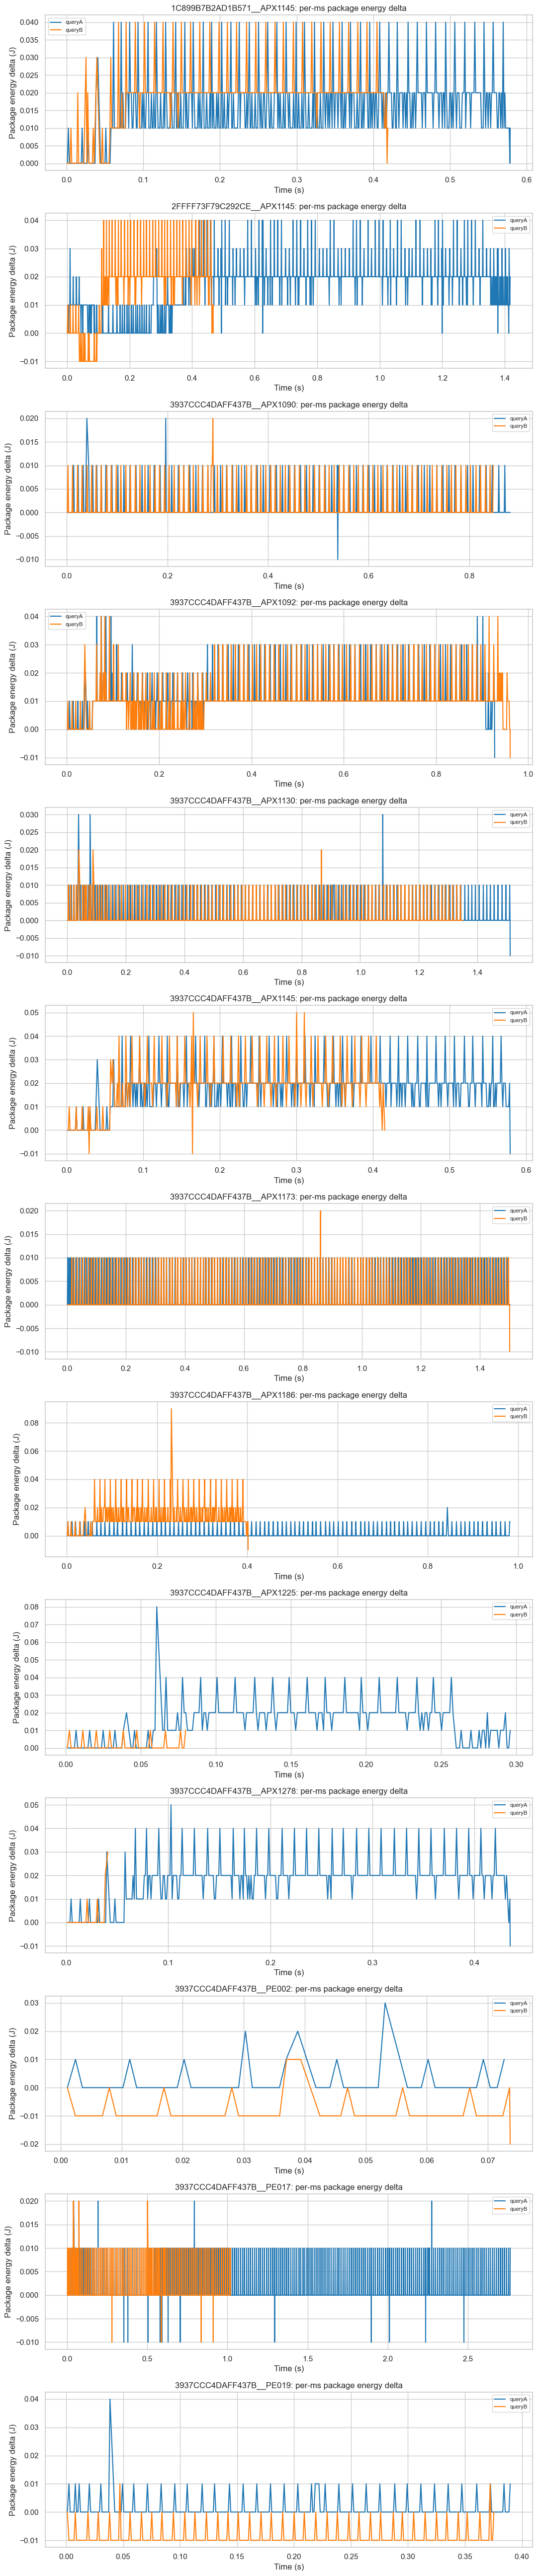

In [11]:
sample_meta = []
for path in sample_files:
    name = path.name
    if "queryA" in name:
        variant = "queryA"
    elif "queryB" in name:
        variant = "queryB"
    else:
        variant = None
    if variant is not None:
        sample_meta.append({"path": path, "variant": variant, "test_group": name.split("-query", 1)[0]})

sample_groups = sorted({row["test_group"] for row in sample_meta})

if not sample_groups:
    print("Need queryA/queryB sample files for per-test comparison.")
else:
    fig, axes = plt.subplots(len(sample_groups), 1, figsize=(11, 4 * len(sample_groups)), squeeze=False)

    for row_index, group in enumerate(sample_groups):
        group_rows = [row for row in sample_meta if row["test_group"] == group]
        first_a = next((row["path"] for row in group_rows if row["variant"] == "queryA"), None)
        first_b = next((row["path"] for row in group_rows if row["variant"] == "queryB"), None)
        plot_ax = axes[row_index, 0]

        if first_a is None or first_b is None:
            plot_ax.text(0.5, 0.5, f"{group}: missing queryA or queryB sample", ha="center", va="center")
            plot_ax.set_axis_off()
            continue

        sample_a = load_sample(first_a).copy()
        sample_b = load_sample(first_b).copy()
        sample_a["pkg_delta_j"] = sample_a["pkg"] - sample_a["pkg"].iloc[0]
        sample_b["pkg_delta_j"] = sample_b["pkg"] - sample_b["pkg"].iloc[0]

        plot_ax.plot(sample_a["timestamp_sec"], sample_a["pkg_delta_j"], label="queryA", color="tab:blue")
        plot_ax.plot(sample_b["timestamp_sec"], sample_b["pkg_delta_j"], label="queryB", color="tab:orange")
        plot_ax.set_title(f"{group}: per-ms package energy delta")
        plot_ax.set_xlabel("Time (s)")
        plot_ax.set_ylabel("Package energy delta (J)")
        plot_ax.legend(fontsize=8)

    plt.tight_layout()

## Cleaner Grouped Comparison by Test Name

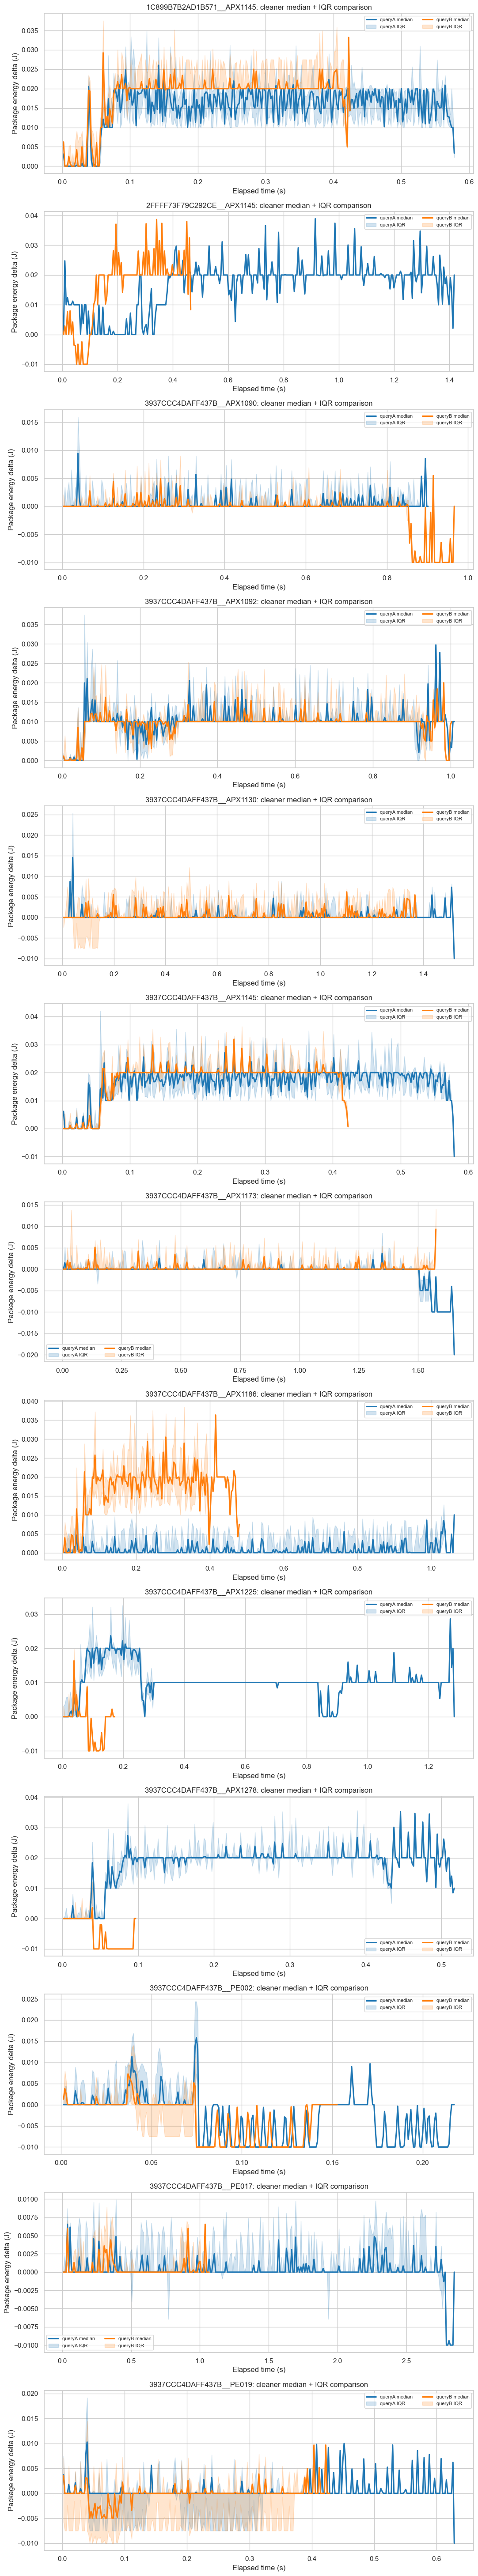

In [13]:
sample_meta = []
for path in sample_files:
    name = path.name
    if "queryA" in name:
        variant = "queryA"
    elif "queryB" in name:
        variant = "queryB"
    else:
        variant = None
    if variant is not None:
        sample_meta.append({"path": path, "variant": variant, "test_group": name.split("-query", 1)[0]})

sample_groups = sorted({row["test_group"] for row in sample_meta})

if not sample_groups:
    print("Need queryA/queryB sample files for grouped comparison.")
else:
    fig, axes = plt.subplots(len(sample_groups), 1, figsize=(11, 4.5 * len(sample_groups)), squeeze=False)
    colors = {"queryA": "tab:blue", "queryB": "tab:orange"}

    def absolute_curve(path: Path, grid: np.ndarray) -> pd.DataFrame:
        sample = load_sample(path).copy()
        sample = sample.sort_values("timestamp_sec")
        sample["pkg_delta_j"] = sample["pkg"] - sample["pkg"].iloc[0]

        t = sample["timestamp_sec"].to_numpy()
        y = sample["pkg_delta_j"].to_numpy()
        if len(t) < 2 or (t.max() - t.min()) == 0:
            return pd.DataFrame({"time_sec": grid, "pkg_delta_j": np.nan})

        unique_t, unique_idx = np.unique(t, return_index=True)
        unique_y = y[unique_idx]
        if len(unique_t) < 2:
            return pd.DataFrame({"time_sec": grid, "pkg_delta_j": np.nan})

        y_interp = np.interp(grid, unique_t, unique_y)
        valid = (grid >= unique_t.min()) & (grid <= unique_t.max())
        y_interp = np.where(valid, y_interp, np.nan)
        return pd.DataFrame({"time_sec": grid, "pkg_delta_j": y_interp})

    for row_index, group in enumerate(sample_groups):
        plot_ax = axes[row_index, 0]
        group_rows = [row for row in sample_meta if row["test_group"] == group]

        longest_time = 0.0
        for row in group_rows:
            sample = load_sample(row["path"])
            if not sample.empty:
                longest_time = max(longest_time, float(sample["timestamp_sec"].max()))

        if longest_time <= 0:
            plot_ax.text(0.5, 0.5, f"{group}: no usable curves", ha="center", va="center")
            plot_ax.set_axis_off()
            continue

        grid = np.linspace(0.0, longest_time, 300)
        curves = []
        for variant in ["queryA", "queryB"]:
            variant_rows = [row for row in group_rows if row["variant"] == variant][:6]
            for row in variant_rows:
                curve = absolute_curve(row["path"], grid)
                curve["variant"] = variant
                curves.append(curve)

        if not curves:
            plot_ax.text(0.5, 0.5, f"{group}: no usable curves", ha="center", va="center")
            plot_ax.set_axis_off()
            continue

        curves_df = pd.concat(curves, ignore_index=True)
        summary = (
            curves_df.groupby(["variant", "time_sec"]) ["pkg_delta_j"]
            .agg(
                median="median",
                q25=lambda s: s.quantile(0.25),
                q75=lambda s: s.quantile(0.75),
            )
            .reset_index()
        )

        for variant in ["queryA", "queryB"]:
            part = summary[summary["variant"] == variant].sort_values("time_sec")
            if part.empty:
                continue
            plot_ax.plot(
                part["time_sec"],
                part["median"],
                color=colors[variant],
                linewidth=2.2,
                label=f"{variant} median",
            )
            plot_ax.fill_between(
                part["time_sec"],
                part["q25"],
                part["q75"],
                color=colors[variant],
                alpha=0.20,
                label=f"{variant} IQR",
            )

        plot_ax.set_title(f"{group}: cleaner median + IQR comparison")
        plot_ax.set_xlabel("Elapsed time (s)")
        plot_ax.set_ylabel("Package energy delta (J)")
        plot_ax.legend(ncol=2, fontsize=8)

    plt.tight_layout()